In [1]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, FixedThresholdClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, classification_report, make_scorer, roc_auc_score, RocCurveDisplay

from src.utils import load_data, split_input_output, split_train_test, serialize_data, deserialize_data
import yaml
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json

# Function

In [2]:
def train_model(model, hyperparam: dict, input_train: pd.DataFrame, output_target: pd.DataFrame):

    """
    To train model 

    Parameters:
        - model : an instance of model (type: instance)
        - hyperparameter : hyperparameter for model cross-validation (type: dict)
        - input_train : input data for training (type: pandas dataftame)
        - output_target : target data for training (type: pandas dataframe)

    Return Values:
        - grid_search : model that fit using Grid Search CV (type: class) 
    """

    compute_support_models = ['LogisticRegression', 'DecisionTreeClassifier', 'SVC']
    scoring = {
        'recall' : 'recall',
        'precision' : 'precision',
        'f1' : 'f1'
    }

    print(f"Model name : {model.__class__.__name__}")
    if model.__class__.__name__ in compute_support_models:
        grid_search = GridSearchCV(
            estimator = model,
            param_grid = hyperparam,
            n_jobs = -1,
            verbose = 3,
            cv = 3,
            scoring = scoring,
            refit = 'recall'
        )
    else :
        grid_search = GridSearchCV(
            estimator = model,
            param_grid = hyperparam,
            verbose = 3,
            cv = 3,
            scoring = scoring,
            refit = 'recall'
        )

    grid_search.fit(input_train, output_target)

    return grid_search

def thresholding_tuning(model, input_train : pd.DataFrame, output_train : pd.DataFrame):

    """ 
    Tuning threshold for model

    Parameters:
        - model : model of machine learning (type: instance)
        - input_train : input data for thresholding (type: pandas dataframe)
        - output_train : output data for thresholding (type: pandas dataframe)

    Return Values:
        - threshold_result : threshold and metric value used (type: list)
    """

    list_threshold = np.linspace(0, 1, 100)
    threshold_result = []

    for threshold in list_threshold:

        tunned_threshold = FixedThresholdClassifier(
            estimator = model,
            threshold = threshold
        )

        y_pred_tunned = tunned_threshold.predict(input_train)
        recall_tunned = recall_score(output_train, y_pred_tunned)
        print(f"Threshold : {round(threshold, 4)} | Recall : {round(recall_tunned, 4)}")
        threshold_result.append({'threshold' : round(threshold, 4), 'recall' : round(recall_tunned, 4)})

    plt.plot(list_threshold, [i['recall'] for i in threshold_result])
    plt.show()

    return threshold_result

def choose_threshold(thershold_result: list, path: str):
    """
    To choose best threshold 

    Parameters:
        - threshold_result : contains threshold and metric value (type: list)
        - path : path used to save best threshold (type: string)

    Return Values:
        - best_thresh : contains best threshold and metric value (type: list)
    """
    
    thershold_result = [thershold_result]
    thresh_list = []
    min_recall = 0.85

    for thresh_element in thershold_result:
        thresh_list.extend(thresh_element)

    df = pd.DataFrame(thresh_list)      
    df_filtered = df[df["recall"] >= min_recall]                      
    df_sorted   = df_filtered.sort_values("threshold", ascending=False)
    best_thresh  = df_sorted.iloc[0].to_dict()

    print("BEST THRESHOLD: ")
    print(f"  Threshold   : {best_thresh['threshold']}")
    print(f"  Recall      : {best_thresh['recall']:.4f}")

    best_threshold_serialize = {
        "threshold" : best_thresh['threshold'],
        "recall" : best_thresh['recall']
    }

    with open(path, 'w') as f:
        json.dump(best_threshold_serialize, f, indent= 4)       
          
    return best_thresh

def model_evaluation(model, threshold : list, input_train : pd.DataFrame, output_train : pd.DataFrame):

    """ 
    Evaluate model 

    Parameters:
        - model : model of machine learning (type: instance)
        - threshold : best threshold from tuning threshold (type: list)
        - input_train : input data for thresholding (type: pandas dataframe)
        - output_train : output data for thresholding (type: pandas dataframe)

    Return Values:
        - report_dict : report of model evaluation (type: dict)
    """

    y_prob = model.predict_proba(input_train)
    y_pred = []
    for prob in y_prob:
        best_class = np.argmax(prob)
        best_prob  = prob[best_class]

        if best_prob >= threshold:
            y_pred.append(best_class)   
        else:
            y_pred.append(1)   

    y_pred = np.array(y_pred)

    report_str = classification_report(
        output_train, y_pred,
        zero_division=0
    )
    print(report_str)

    report_dict = classification_report(
        output_train, y_pred,
        output_dict=True,
        zero_division=0
    )
    auc = roc_auc_score(output_train, y_prob[:,1])
    print(f"Model : {auc}")
    RocCurveDisplay.from_predictions(output_train, y_prob[:, 1])
    plt.show()

    return report_dict

# Load Data

In [3]:
with open ('../config/path.yaml', 'r') as f:
    path = yaml.safe_load(f)

X_TRAIN_ROS_PATH = path['data_path']['data']['processed']['X_train_ros']
Y_TRAIN_ROS_PATH = path['data_path']['data']['processed']['y_train_ros']
X_VALID_PATH = path['data_path']['data']['processed']['X_valid_prep']
Y_VALID_PATH = path['data_path']['output']['y_valid']
X_TEST_PATH = path['data_path']['data']['processed']['X_test_prep']
Y_TEST_PATH = path['data_path']['output']['y_test']

LOGREG_MODEL_PATH = path['data_path']['models']['logreg_model']
DESTREE_MODEL_PATH = path['data_path']['models']['destree_model']
RANDFOR_MODEL_PATH = path['data_path']['models']['randfor_model']
SUPVEC_MODEL_PATH = path['data_path']['models']['supvec_model']

LOGREG_THRESHOLD_PATH = path['param_path']['threshold']['logistic_regression']
DESTREE_THRESHOLD_PATH = path['param_path']['threshold']['decision_tree']
RANDFOR_THRESHOLD_PATH = path['param_path']['threshold']['random_forest']
SUPVEC_THRESHOLD_PATH = path['param_path']['threshold']['super_vector']

In [4]:
X_train_ros = deserialize_data(X_TRAIN_ROS_PATH)
y_train_ros = deserialize_data(Y_TRAIN_ROS_PATH)
X_valid_prep = deserialize_data(X_VALID_PATH)
y_valid = deserialize_data(Y_VALID_PATH)
X_test_prep = deserialize_data(X_TEST_PATH)
y_test = deserialize_data(Y_TEST_PATH)

Succeed to deserialize data
Succeed to deserialize data
Succeed to deserialize data
Succeed to deserialize data
Succeed to deserialize data
Succeed to deserialize data


In [5]:
X_train_ros.shape

(40408, 26)

# Modelling

In [6]:
logreg_hyperparameter = {
    'solver'  : ['saga', 'liblinear'],
    'penalty' : ['l2', 'l1'],
    'max_iter' : [500, 1000, 2000]
}

decistree_hyperparameter = {
    'max_depth' : [5, 15],
    'min_samples_split' : [2, 10],
    'min_samples_leaf' : [1, 5],
    'max_features' : [None, 'sqrt'],
}

randforest_hyperparameter ={
    'n_estimators' : [100, 200],
    'max_depth' : [None, 10],
    'min_samples_split' : [2, 10],
    'max_leaf_nodes' : [None, 3]
}

supvec_hyperparameter = {
    'C' : [0.1, 10],
    'kernel' : ['rbf'],
}


In [7]:
dummy_clf = DummyClassifier(strategy= "stratified", random_state= 42)

base_model = train_model(dummy_clf, {}, X_train_ros, y_train_ros)

Model name : DummyClassifier
Fitting 3 folds for each of 1 candidates, totalling 3 fits
[CV 1/3] END  f1: (test=0.500) precision: (test=0.497) recall: (test=0.502) total time=   0.0s
[CV 2/3] END  f1: (test=0.507) precision: (test=0.504) recall: (test=0.510) total time=   0.0s
[CV 3/3] END  f1: (test=0.493) precision: (test=0.496) recall: (test=0.490) total time=   0.0s


In [8]:
logreg_instance = LogisticRegression(
    random_state = 42
)

destree_instance  = DecisionTreeClassifier(
    random_state = 42
)

randfor_instance  = RandomForestClassifier(
    random_state = 42
)

supvec_instance = SVC(
    random_state = 42,
    probability = True
)

logreg_model = train_model(logreg_instance, logreg_hyperparameter, X_train_ros, y_train_ros)
destree_model = train_model(destree_instance, decistree_hyperparameter, X_train_ros, y_train_ros)
randfor_model = train_model(randfor_instance, randforest_hyperparameter, X_train_ros, y_train_ros)
supvec_model = train_model(supvec_instance, supvec_hyperparameter, X_train_ros, y_train_ros)

Model name : LogisticRegression
Fitting 3 folds for each of 12 candidates, totalling 36 fits
[CV 2/3] END max_iter=500, penalty=l2, solver=liblinear; f1: (test=0.745) precision: (test=0.712) recall: (test=0.782) total time=   0.2s
[CV 3/3] END max_iter=500, penalty=l2, solver=liblinear; f1: (test=0.737) precision: (test=0.703) recall: (test=0.775) total time=   0.2s
[CV 1/3] END max_iter=500, penalty=l2, solver=liblinear; f1: (test=0.744) precision: (test=0.715) recall: (test=0.774) total time=   0.2s
[CV 1/3] END max_iter=500, penalty=l1, solver=liblinear; f1: (test=0.791) precision: (test=0.810) recall: (test=0.773) total time=   0.6s
[CV 3/3] END max_iter=500, penalty=l1, solver=liblinear; f1: (test=0.792) precision: (test=0.812) recall: (test=0.774) total time=   0.6s
[CV 1/3] END max_iter=1000, penalty=l2, solver=liblinear; f1: (test=0.744) precision: (test=0.715) recall: (test=0.774) total time=   0.2s
[CV 2/3] END max_iter=1000, penalty=l2, solver=liblinear; f1: (test=0.745) pre

/home/vega33/VEGA_ML_PROCESS/vega_venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 1/3] END max_iter=500, penalty=l2, solver=saga; f1: (test=0.645) precision: (test=0.685) recall: (test=0.608) total time=  18.1s
[CV 2/3] END max_iter=2000, penalty=l1, solver=liblinear; f1: (test=0.796) precision: (test=0.812) recall: (test=0.779) total time=   0.9s
[CV 3/3] END max_iter=2000, penalty=l1, solver=liblinear; f1: (test=0.792) precision: (test=0.812) recall: (test=0.774) total time=   0.6s


/home/vega33/VEGA_ML_PROCESS/vega_venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 1/3] END max_iter=500, penalty=l1, solver=saga; f1: (test=0.645) precision: (test=0.685) recall: (test=0.608) total time=  19.1s
[CV 2/3] END max_iter=2000, penalty=l2, solver=saga; f1: (test=0.645) precision: (test=0.684) recall: (test=0.610) total time=  10.9s
[CV 3/3] END max_iter=2000, penalty=l2, solver=saga; f1: (test=0.651) precision: (test=0.686) recall: (test=0.619) total time=  11.1s
[CV 3/3] END max_iter=2000, penalty=l1, solver=saga; f1: (test=0.651) precision: (test=0.686) recall: (test=0.619) total time=  11.6s
[CV 2/3] END max_iter=2000, penalty=l1, solver=saga; f1: (test=0.645) precision: (test=0.684) recall: (test=0.610) total time=  11.7s


...

[CV 1/3] END max_iter=1000, penalty=l1, solver=saga; f1: (test=0.645) precision: (test=0.685) recall: (test=0.608) total time=  30.9s


/home/vega33/VEGA_ML_PROCESS/vega_venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 1/3] END max_iter=2000, penalty=l2, solver=saga; f1: (test=0.645) precision: (test=0.685) recall: (test=0.609) total time=  39.3s


/home/vega33/VEGA_ML_PROCESS/vega_venv/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


[CV 1/3] END max_iter=2000, penalty=l1, solver=saga; f1: (test=0.645) precision: (test=0.685) recall: (test=0.609) total time=  42.1s
Model name : DecisionTreeClassifier
Fitting 3 folds for each of 16 candidates, totalling 48 fits
[CV 1/3] END max_depth=5, max_features=None, min_samples_leaf=1, min_samples_split=2; f1: (test=0.810) precision: (test=0.901) recall: (test=0.736) total time=   0.1s
[CV 2/3] END max_depth=5, max_features=None, min_samples_leaf=1, min_samples_split=2; f1: (test=0.818) precision: (test=0.912) recall: (test=0.741) total time=   0.1s
[CV 3/3] END max_depth=5, max_features=None, min_samples_leaf=1, min_samples_split=2; f1: (test=0.809) precision: (test=0.906) recall: (test=0.731) total time=   0.1s
[CV 1/3] END max_depth=5, max_features=None, min_samples_leaf=1, min_samples_split=10; f1: (test=0.810) precision: (test=0.901) recall: (test=0.736) total time=   0.1s
[CV 2/3] END max_depth=5, max_features=None, min_samples_leaf=1, min_samples_split=10; f1: (test=0.8

In [9]:
serialize_data(logreg_model, LOGREG_MODEL_PATH)
serialize_data(destree_model, DESTREE_MODEL_PATH)
serialize_data(randfor_model, RANDFOR_MODEL_PATH)
serialize_data(supvec_model, SUPVEC_MODEL_PATH)

Succeed to serialize data
Succeed to serialize data
Succeed to serialize data
Succeed to serialize data


# Threshold Tuning

Threshold : 0.0 | Recall : 1.0
Threshold : 0.0101 | Recall : 0.5077
Threshold : 0.0202 | Recall : 0.5077
Threshold : 0.0303 | Recall : 0.5077
Threshold : 0.0404 | Recall : 0.5077
Threshold : 0.0505 | Recall : 0.5077
Threshold : 0.0606 | Recall : 0.5077
Threshold : 0.0707 | Recall : 0.5077
Threshold : 0.0808 | Recall : 0.5077
Threshold : 0.0909 | Recall : 0.5077
Threshold : 0.101 | Recall : 0.5077
Threshold : 0.1111 | Recall : 0.5077
Threshold : 0.1212 | Recall : 0.5077
Threshold : 0.1313 | Recall : 0.5077
Threshold : 0.1414 | Recall : 0.5077
Threshold : 0.1515 | Recall : 0.5077
Threshold : 0.1616 | Recall : 0.5077
Threshold : 0.1717 | Recall : 0.5077
Threshold : 0.1818 | Recall : 0.5077
Threshold : 0.1919 | Recall : 0.5077
Threshold : 0.202 | Recall : 0.5077
Threshold : 0.2121 | Recall : 0.5077
Threshold : 0.2222 | Recall : 0.5077
Threshold : 0.2323 | Recall : 0.5077
Threshold : 0.2424 | Recall : 0.5077
Threshold : 0.2525 | Recall : 0.5077
Threshold : 0.2626 | Recall : 0.5077
Threshold

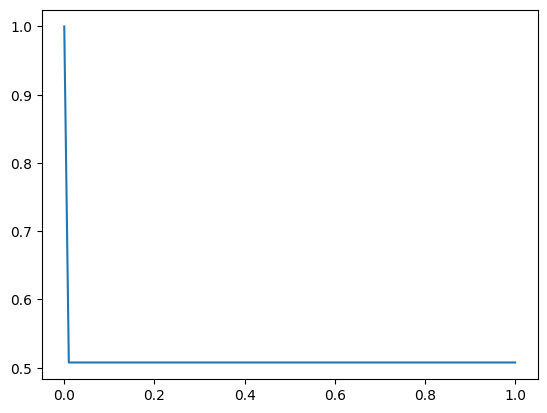

In [10]:
thresh_baseline = thresholding_tuning(base_model, X_valid_prep, y_valid)

Threshold : 0.0 | Recall : 1.0
Threshold : 0.0101 | Recall : 0.9958
Threshold : 0.0202 | Recall : 0.993
Threshold : 0.0303 | Recall : 0.9916
Threshold : 0.0404 | Recall : 0.9887
Threshold : 0.0505 | Recall : 0.9873
Threshold : 0.0606 | Recall : 0.9845
Threshold : 0.0707 | Recall : 0.9817
Threshold : 0.0808 | Recall : 0.9789
Threshold : 0.0909 | Recall : 0.9761
Threshold : 0.101 | Recall : 0.9733
Threshold : 0.1111 | Recall : 0.9733
Threshold : 0.1212 | Recall : 0.9705
Threshold : 0.1313 | Recall : 0.9662
Threshold : 0.1414 | Recall : 0.9648
Threshold : 0.1515 | Recall : 0.9592
Threshold : 0.1616 | Recall : 0.9522
Threshold : 0.1717 | Recall : 0.9494
Threshold : 0.1818 | Recall : 0.948
Threshold : 0.1919 | Recall : 0.9466
Threshold : 0.202 | Recall : 0.9451
Threshold : 0.2121 | Recall : 0.9409
Threshold : 0.2222 | Recall : 0.9409
Threshold : 0.2323 | Recall : 0.9409
Threshold : 0.2424 | Recall : 0.9409
Threshold : 0.2525 | Recall : 0.9381
Threshold : 0.2626 | Recall : 0.9339
Threshold :

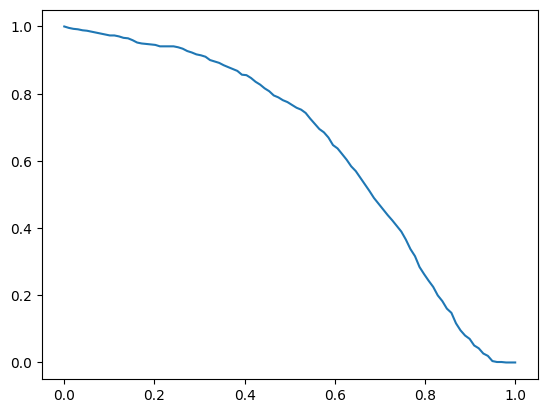

In [11]:
thresh_logreg = thresholding_tuning(logreg_model, X_valid_prep, y_valid)

Threshold : 0.0 | Recall : 1.0
Threshold : 0.0101 | Recall : 0.8734
Threshold : 0.0202 | Recall : 0.8734
Threshold : 0.0303 | Recall : 0.872
Threshold : 0.0404 | Recall : 0.872
Threshold : 0.0505 | Recall : 0.872
Threshold : 0.0606 | Recall : 0.872
Threshold : 0.0707 | Recall : 0.8678
Threshold : 0.0808 | Recall : 0.8678
Threshold : 0.0909 | Recall : 0.8664
Threshold : 0.101 | Recall : 0.865
Threshold : 0.1111 | Recall : 0.8608
Threshold : 0.1212 | Recall : 0.8608
Threshold : 0.1313 | Recall : 0.8467
Threshold : 0.1414 | Recall : 0.8467
Threshold : 0.1515 | Recall : 0.8425
Threshold : 0.1616 | Recall : 0.834
Threshold : 0.1717 | Recall : 0.834
Threshold : 0.1818 | Recall : 0.834
Threshold : 0.1919 | Recall : 0.8312
Threshold : 0.202 | Recall : 0.8256
Threshold : 0.2121 | Recall : 0.8256
Threshold : 0.2222 | Recall : 0.8115
Threshold : 0.2323 | Recall : 0.8115
Threshold : 0.2424 | Recall : 0.8087
Threshold : 0.2525 | Recall : 0.8073
Threshold : 0.2626 | Recall : 0.8059
Threshold : 0.272

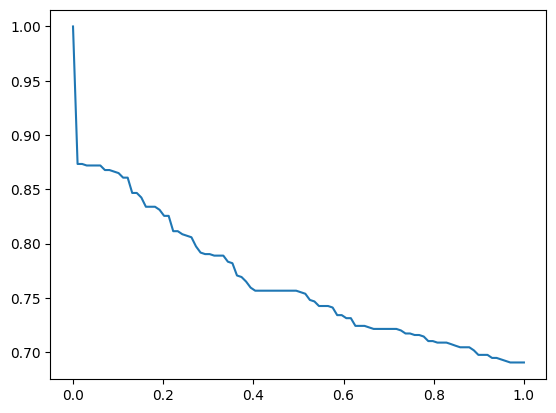

In [12]:
thresh_destree = thresholding_tuning(destree_model, X_valid_prep, y_valid)

Threshold : 0.0 | Recall : 1.0
Threshold : 0.0101 | Recall : 0.9958
Threshold : 0.0202 | Recall : 0.993
Threshold : 0.0303 | Recall : 0.9902
Threshold : 0.0404 | Recall : 0.9845
Threshold : 0.0505 | Recall : 0.9789
Threshold : 0.0606 | Recall : 0.9705
Threshold : 0.0707 | Recall : 0.9606
Threshold : 0.0808 | Recall : 0.9466
Threshold : 0.0909 | Recall : 0.9423
Threshold : 0.101 | Recall : 0.9339
Threshold : 0.1111 | Recall : 0.9297
Threshold : 0.1212 | Recall : 0.917
Threshold : 0.1313 | Recall : 0.9142
Threshold : 0.1414 | Recall : 0.9015
Threshold : 0.1515 | Recall : 0.8945
Threshold : 0.1616 | Recall : 0.8847
Threshold : 0.1717 | Recall : 0.8805
Threshold : 0.1818 | Recall : 0.8748
Threshold : 0.1919 | Recall : 0.872
Threshold : 0.202 | Recall : 0.8636
Threshold : 0.2121 | Recall : 0.8565
Threshold : 0.2222 | Recall : 0.8509
Threshold : 0.2323 | Recall : 0.8439
Threshold : 0.2424 | Recall : 0.8397
Threshold : 0.2525 | Recall : 0.8354
Threshold : 0.2626 | Recall : 0.8284
Threshold : 

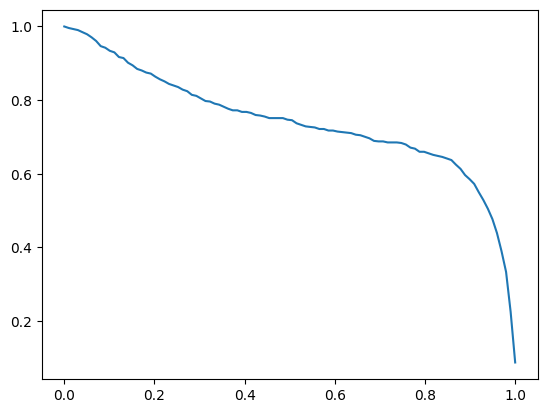

In [13]:
thresh_randfor = thresholding_tuning(randfor_model, X_valid_prep, y_valid)

Threshold : 0.0 | Recall : 1.0
Threshold : 0.0101 | Recall : 1.0
Threshold : 0.0202 | Recall : 1.0
Threshold : 0.0303 | Recall : 1.0
Threshold : 0.0404 | Recall : 1.0
Threshold : 0.0505 | Recall : 1.0
Threshold : 0.0606 | Recall : 1.0
Threshold : 0.0707 | Recall : 1.0
Threshold : 0.0808 | Recall : 1.0
Threshold : 0.0909 | Recall : 1.0
Threshold : 0.101 | Recall : 1.0
Threshold : 0.1111 | Recall : 1.0
Threshold : 0.1212 | Recall : 1.0
Threshold : 0.1313 | Recall : 1.0
Threshold : 0.1414 | Recall : 0.9986
Threshold : 0.1515 | Recall : 0.993
Threshold : 0.1616 | Recall : 0.9887
Threshold : 0.1717 | Recall : 0.9831
Threshold : 0.1818 | Recall : 0.9817
Threshold : 0.1919 | Recall : 0.9803
Threshold : 0.202 | Recall : 0.9719
Threshold : 0.2121 | Recall : 0.9606
Threshold : 0.2222 | Recall : 0.9522
Threshold : 0.2323 | Recall : 0.9395
Threshold : 0.2424 | Recall : 0.9269
Threshold : 0.2525 | Recall : 0.9044
Threshold : 0.2626 | Recall : 0.8833
Threshold : 0.2727 | Recall : 0.865
Threshold : 0

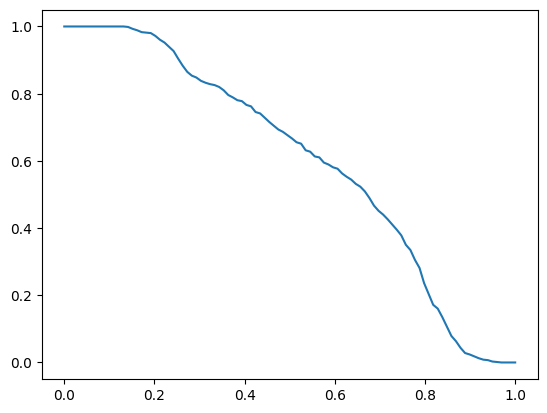

In [14]:
thresh_supvec = thresholding_tuning(supvec_model, X_valid_prep, y_valid)

In [15]:
print(thresh_supvec)

[{'threshold': np.float64(0.0), 'recall': 1.0}, {'threshold': np.float64(0.0101), 'recall': 1.0}, {'threshold': np.float64(0.0202), 'recall': 1.0}, {'threshold': np.float64(0.0303), 'recall': 1.0}, {'threshold': np.float64(0.0404), 'recall': 1.0}, {'threshold': np.float64(0.0505), 'recall': 1.0}, {'threshold': np.float64(0.0606), 'recall': 1.0}, {'threshold': np.float64(0.0707), 'recall': 1.0}, {'threshold': np.float64(0.0808), 'recall': 1.0}, {'threshold': np.float64(0.0909), 'recall': 1.0}, {'threshold': np.float64(0.101), 'recall': 1.0}, {'threshold': np.float64(0.1111), 'recall': 1.0}, {'threshold': np.float64(0.1212), 'recall': 1.0}, {'threshold': np.float64(0.1313), 'recall': 1.0}, {'threshold': np.float64(0.1414), 'recall': 0.9986}, {'threshold': np.float64(0.1515), 'recall': 0.993}, {'threshold': np.float64(0.1616), 'recall': 0.9887}, {'threshold': np.float64(0.1717), 'recall': 0.9831}, {'threshold': np.float64(0.1818), 'recall': 0.9817}, {'threshold': np.float64(0.1919), 'reca

In [16]:
best_thresh_logreg = choose_threshold(thresh_logreg, LOGREG_THRESHOLD_PATH)

BEST THRESHOLD: 
  Threshold   : 0.404
  Recall      : 0.8551


In [17]:
best_thresh_destree = choose_threshold(thresh_destree, DESTREE_THRESHOLD_PATH)

BEST THRESHOLD: 
  Threshold   : 0.1212
  Recall      : 0.8608


In [18]:
best_thresh_randfor = choose_threshold(thresh_randfor, RANDFOR_THRESHOLD_PATH)

BEST THRESHOLD: 
  Threshold   : 0.2222
  Recall      : 0.8509


In [19]:
best_thresh_supvec = choose_threshold(thresh_supvec, SUPVEC_THRESHOLD_PATH)

BEST THRESHOLD: 
  Threshold   : 0.2828
  Recall      : 0.8537


# Model Evaluation

              precision    recall  f1-score   support

           0       0.93      0.73      0.82      2548
           1       0.45      0.79      0.57       711

    accuracy                           0.74      3259
   macro avg       0.69      0.76      0.70      3259
weighted avg       0.82      0.74      0.76      3259

Model : 0.8434148732521246


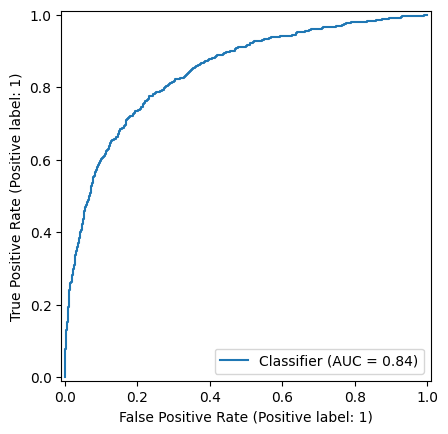

In [20]:
logreg_eval = model_evaluation(logreg_model, best_thresh_logreg['threshold'], X_test_prep, y_test)

              precision    recall  f1-score   support

           0       0.92      0.93      0.92      2548
           1       0.73      0.73      0.73       711

    accuracy                           0.88      3259
   macro avg       0.83      0.83      0.83      3259
weighted avg       0.88      0.88      0.88      3259

Model : 0.8531199561940972


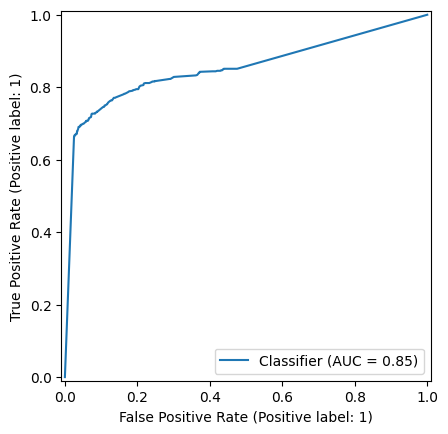

In [21]:
destree_eval = model_evaluation(destree_model, best_thresh_destree['threshold'], X_test_prep, y_test)

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      2548
           1       0.95      0.72      0.82       711

    accuracy                           0.93      3259
   macro avg       0.94      0.85      0.89      3259
weighted avg       0.93      0.93      0.93      3259

Model : 0.9304526094761176


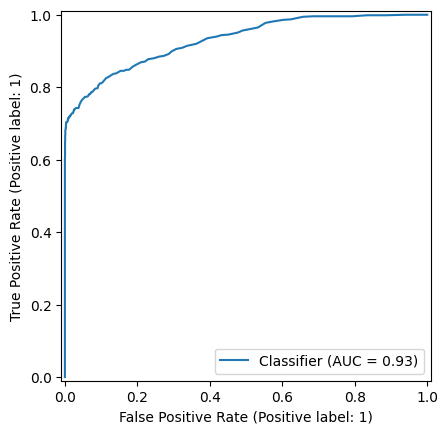

In [22]:
randfor_eval = model_evaluation(randfor_model, best_thresh_randfor['threshold'], X_test_prep, y_test)

              precision    recall  f1-score   support

           0       0.88      0.72      0.79      2548
           1       0.39      0.66      0.49       711

    accuracy                           0.71      3259
   macro avg       0.64      0.69      0.64      3259
weighted avg       0.78      0.71      0.73      3259

Model : 0.7611595758069538


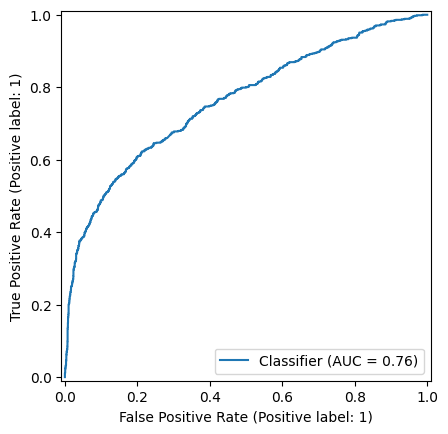

In [23]:
supvec_eval = model_evaluation(supvec_model, best_thresh_supvec['threshold'], X_test_prep, y_test)